In [ ]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

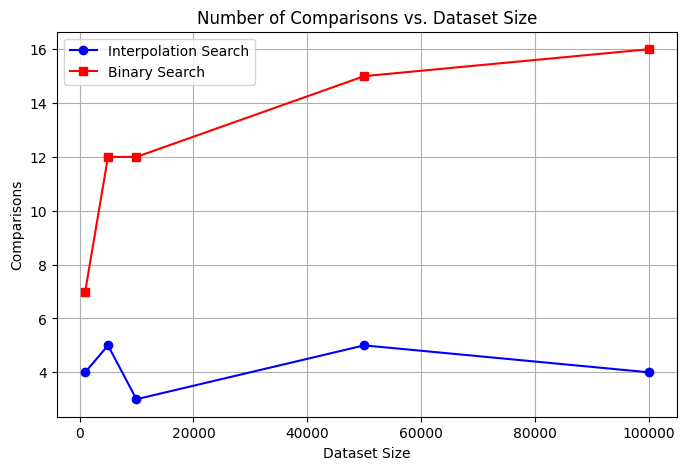

In [3]:
import random
import time
import matplotlib.pyplot as plt

def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            return (low, comparisons) if arr[low] == target else (-1, comparisons)
        
        
        pos = low + int(((target - arr[low]) * (high - low)) / (arr[high] - arr[low]))
        
        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1, comparisons

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons


sizes = [1000, 5000, 10000, 50000, 100000]
is_comps, bs_comps = [], []

for size in sizes:
    arr = sorted(random.sample(range(size * 10), size))
    target = arr[random.randint(0, size - 1)]
    
    _, comp_is = interpolation_search(arr, target)
    _, comp_bs = binary_search(arr, target)
    
    is_comps.append(comp_is)
    bs_comps.append(comp_bs)


plt.figure(figsize=(8, 5))
plt.plot(sizes, is_comps, marker='o', color='blue', label='Interpolation Search')
plt.plot(sizes, bs_comps, marker='s', color='red', label='Binary Search')
plt.title('Number of Comparisons vs. Dataset Size')
plt.xlabel('Dataset Size')
plt.ylabel('Comparisons')
plt.legend()
plt.grid(True)
plt.show()
